# SETUP

In [46]:
# Janky code to do different setup when run in a Colab notebook vs VSCode
import os

from IPython import get_ipython

ipython = get_ipython()
# Code to automatically update the HookedTransformer code as its edited without restarting the kernel
ipython.magic("load_ext autoreload")
ipython.magic("autoreload 2")

# Import stuff
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import tqdm.notebook as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from torchtyping import TensorType as TT
from typing import List, Union, Optional, Callable
from functools import partial
import copy
import itertools
import json

from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML, Markdown
import umap

/var/folders/jq/3qm60jc56v336bp7cy96fxgm0000gn/T/ipykernel_5884/2315760820.py:8: DeprecationWarning:

`magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).

/var/folders/jq/3qm60jc56v336bp7cy96fxgm0000gn/T/ipykernel_5884/2315760820.py:9: DeprecationWarning:

`magic(...)` is deprecated since IPython 0.13 (warning added in 8.1), use run_line_magic(magic_name, parameter_s).



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

In [3]:
from neel_plotly import line, imshow, scatter
import plotly.io as pio
pio.renderers.default = 'vscode'

import transformer_lens.patching as patching

from typing_extensions import Literal

## IOI SETUP

In [4]:
model = HookedTransformer.from_pretrained("gpt2-small")


model.set_use_attn_result(True)
model.set_use_attn_in(True)
model.set_use_hook_mlp_in(True)

Loaded pretrained model gpt2-small into HookedTransformer


In [5]:
prompts = [
    "When John and Mary went to the shops, John gave the bag to",
    "When John and Mary went to the shops, Mary gave the bag to",
    "When Tom and James went to the park, James gave the ball to",
    "When Tom and James went to the park, Tom gave the ball to",
    "When Dan and Sid went to the shops, Sid gave an apple to",
    "When Dan and Sid went to the shops, Dan gave an apple to",
    "After Martin and Amy went to the park, Amy gave a drink to",
    "After Martin and Amy went to the park, Martin gave a drink to",
]
answers = [
    (" Mary", " John"),
    (" John", " Mary"),
    (" Tom", " James"),
    (" James", " Tom"),
    (" Dan", " Sid"),
    (" Sid", " Dan"),
    (" Martin", " Amy"),
    (" Amy", " Martin"),
]

clean_tokens = model.to_tokens(prompts)
# Swap each adjacent pair, with a hacky list comprehension
corrupted_tokens = clean_tokens[
    [(i + 1 if i % 2 == 0 else i - 1) for i in range(len(clean_tokens))]
]
print("Clean string 0", model.to_string(clean_tokens[0]))
print("Corrupted string 0", model.to_string(corrupted_tokens[0]))

answer_token_indices = torch.tensor(
    [
        [model.to_single_token(answers[i][j]) for j in range(2)]
        for i in range(len(answers))
    ],
    device=model.cfg.device,
)
print("Answer token indices", answer_token_indices)

Clean string 0 <|endoftext|>When John and Mary went to the shops, John gave the bag to
Corrupted string 0 <|endoftext|>When John and Mary went to the shops, Mary gave the bag to
Answer token indices tensor([[ 5335,  1757],
        [ 1757,  5335],
        [ 4186,  3700],
        [ 3700,  4186],
        [ 6035, 15686],
        [15686,  6035],
        [ 5780, 14235],
        [14235,  5780]], device='mps:0')


In [6]:
def get_logit_diff(logits, answer_token_indices=answer_token_indices):
    if len(logits.shape) == 3:
        # Get final logits only
        logits = logits[:, -1, :]
    correct_logits = logits.gather(1, answer_token_indices[:, 0].unsqueeze(1))
    incorrect_logits = logits.gather(1, answer_token_indices[:, 1].unsqueeze(1))
    return (correct_logits - incorrect_logits).mean()


clean_logits, clean_cache = model.run_with_cache(clean_tokens)
corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_logit_diff = get_logit_diff(clean_logits, answer_token_indices).item()
print(f"Clean logit diff: {clean_logit_diff:.4f}")

corrupted_logit_diff = get_logit_diff(corrupted_logits, answer_token_indices).item()
print(f"Corrupted logit diff: {corrupted_logit_diff:.4f}")

Clean logit diff: 3.5519
Corrupted logit diff: -3.5519


In [7]:
CLEAN_BASELINE = clean_logit_diff
CORRUPTED_BASELINE = corrupted_logit_diff


def ioi_metric(logits, answer_token_indices=answer_token_indices):
    return (get_logit_diff(logits, answer_token_indices) - CORRUPTED_BASELINE) / (
        CLEAN_BASELINE - CORRUPTED_BASELINE
    )

In [8]:
def filter_mlp_hooks(name):
    return "mlp" in name

def get_cache_fwd_and_bwd(model, tokens, metric):
    model.reset_hooks()
    cache = {}

    def forward_cache_hook(act, hook):
        cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, forward_cache_hook, "fwd")

    grad_cache = {}

    def backward_cache_hook(act, hook):
        grad_cache[hook.name] = act.detach()

    model.add_hook(filter_mlp_hooks, backward_cache_hook, "bwd")

    value = metric(model(tokens))
    value.backward()
    model.reset_hooks()
    return (
        value.item(),
        ActivationCache(cache, model),
        ActivationCache(grad_cache, model),
    )

clean_value, clean_cache, clean_grad_cache = get_cache_fwd_and_bwd(
    model, clean_tokens, ioi_metric
)

corrupted_value, corrupted_cache, corrupted_grad_cache = get_cache_fwd_and_bwd(
    model, corrupted_tokens, ioi_metric
)


In [9]:
def stack_mlp_from_cache(cache, activation_name: Literal["mlp_in", "mlp_out", "pre", "post"]):
    stacked_mlp_vectors = torch.stack(
        [cache[activation_name, l] for l in range(model.cfg.n_layers)], dim=0
    )

    return stacked_mlp_vectors

# Clustering Neurons 

## Computing Attribution Vectors

In [28]:
num_layers = model.cfg.n_layers

def stack_w_out():
    W_out_stacked = torch.stack(
        [model.blocks[l].mlp.W_out for l in range(num_layers)], dim=0
    )

    return W_out_stacked


def get_mlp_output_attribution_matrices(clean_cache, sum_over_pos=True, weighted_by_attribution_score=False):
    clean_act_post = stack_mlp_from_cache(clean_cache, "post")

    clean_act_post = einops.reduce(
        clean_act_post,
        "layer batch pos dim -> layer pos dim",
        "sum"
    )

    W_out_stacked = stack_w_out()

    W_out_stacked = einops.rearrange(
        W_out_stacked,
        "layer d_mlp d_embed -> layer d_embed d_mlp"
    )

    attribution_matrices = einops.einsum(
        clean_act_post,
        W_out_stacked,
        "layer pos d_mlp, layer d_embed d_mlp -> layer pos d_embed d_mlp"
    )


    attribution_matrices = einops.rearrange(
        attribution_matrices,
        "layer pos d_embed d_mlp -> layer pos d_mlp d_embed"
    )
        
    if(weighted_by_attribution_score):
        clean_act = stack_mlp_from_cache(clean_cache, "post")
        corrupted_act = stack_mlp_from_cache(corrupted_cache, "post")
        grad_vector = stack_mlp_from_cache(corrupted_grad_cache, "post")
        
        attribution_scores = einops.reduce(
            grad_vector * (clean_act - corrupted_act),
            "layer batch pos dim -> layer pos dim",
            "sum"
        )

        attribution_matrices = einops.einsum(
            attribution_scores,
            attribution_matrices,
            "layer pos d_mlp, layer pos d_mlp d_embed -> layer pos d_mlp d_embed"
        )
    
    if(sum_over_pos):
        attribution_matrices = einops.reduce(
            attribution_matrices,
            "layer pos d_mlp d_embed -> layer d_mlp d_embed",
            "sum"
        )
    
    return attribution_matrices 


def throw_low_activation_neuron(clean_cache, attributions, threshold=0.1):
    clean_act = stack_mlp_from_cache(clean_cache, "post")
    
    clean_act = einops.reduce(
        torch.abs(clean_act),
        "layer batch pos d_mlp -> layer pos d_mlp",
        "sum"
    )
    
    clean_act = einops.reduce(
        torch.abs(clean_act),
        "layer pos d_mlp -> layer d_mlp",
        "sum"
    )
    mask = clean_act > threshold
    
    while(mask.dim() < attributions.dim()):
        mask = mask.unsqueeze(-1)
    
    mask = mask.expand_as(attributions)
    
    filtered_out = attributions * mask
    
    return filtered_out    

## Unweighted Clustering

In [68]:
attr = get_mlp_output_attribution_matrices(clean_cache)
attr = throw_low_activation_neuron(clean_cache, attr, threshold=3)

### Cluster

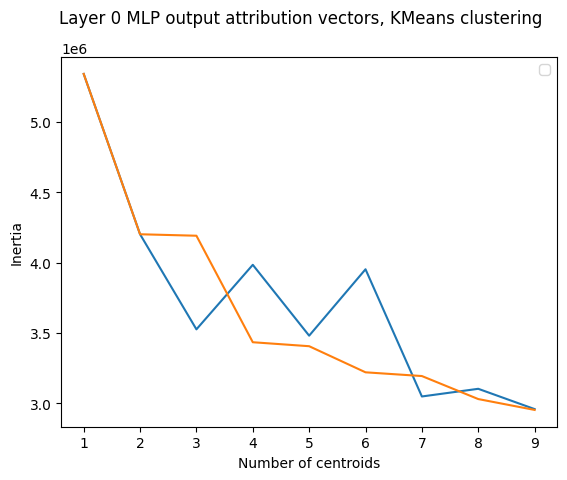

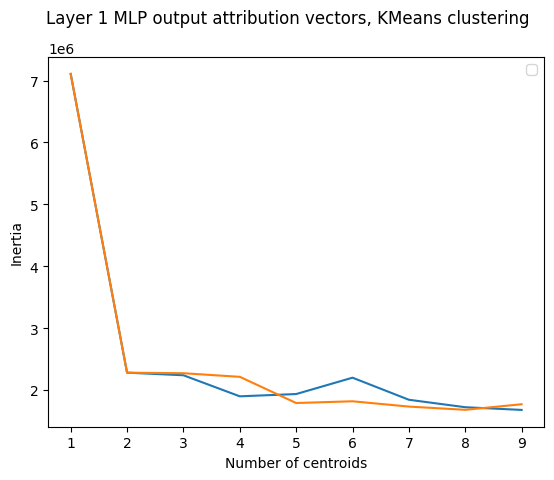

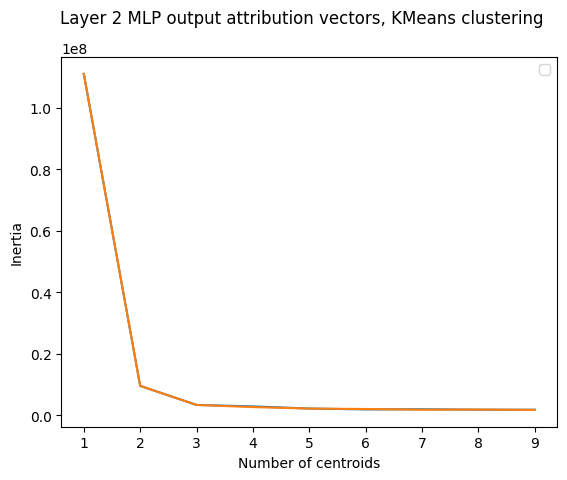

In [69]:
from sklearn.cluster import KMeans

max_centroids = 10
for l in range(3):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    # plot the inertias using matplot lib
    fig, ax = plt.subplots()
    fig.suptitle(f"Layer {l} MLP output attribution vectors, KMeans clustering")
    plt.legend(["All neurons", "Filtered neurons"])
    ax.set_xlabel("Number of centroids")
    ax.set_ylabel("Inertia")
    ax.plot(range(1,max_centroids), inertias)
    ax.plot(range(1,max_centroids), filtered_inertias)

### Plot

In [76]:
embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    embeddings.append(reducer.fit_transform(attr[l,non_empty_mask,:].cpu().detach().numpy()))

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/ut

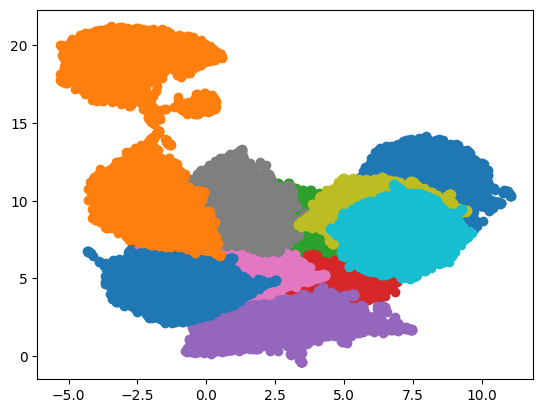

In [77]:
for l in range(num_layers):
    plt.scatter(embeddings[l][:,0], embeddings[l][:,1])

## Weighted Clustering

In [67]:
attr = get_mlp_output_attribution_matrices(clean_cache, weighted_by_attribution_score=True)
attr = throw_low_activation_neuron(clean_cache, attr, threshold=40)

### Cluster

#### UnFiltered

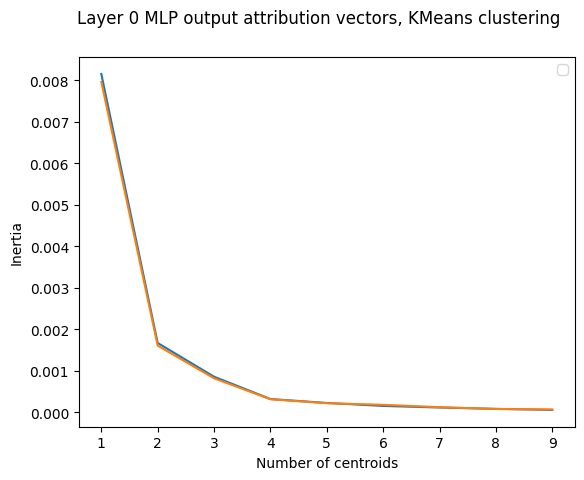

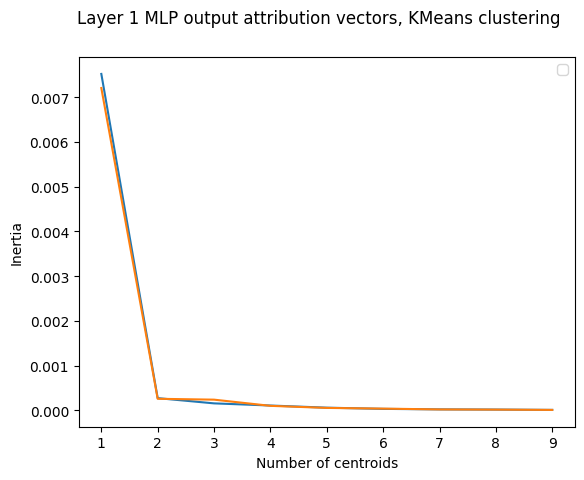

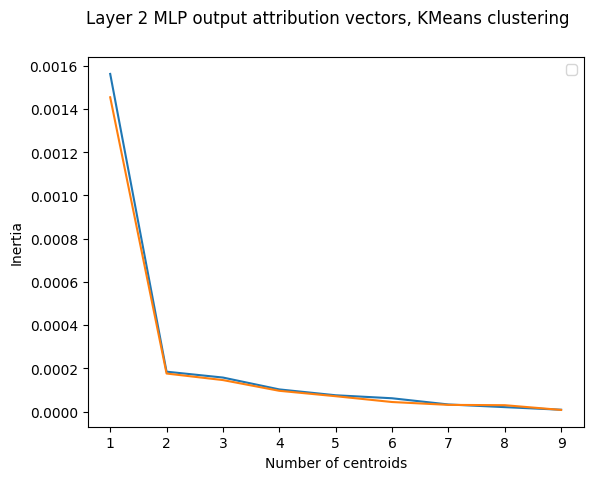

In [66]:
from sklearn.cluster import KMeans

max_centroids = 10
for l in range(3):
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    filtered_data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    data = attr[l].cpu().detach().numpy()
    inertias = []
    filtered_inertias = []

    for i in range(1,max_centroids):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        kmeans.fit(filtered_data)
        filtered_inertias.append(kmeans.inertia_)
        
    # plot the inertias using matplot lib
    fig, ax = plt.subplots()
    fig.suptitle(f"Layer {l} MLP output attribution vectors, KMeans clustering")
    plt.legend(["All neurons", "Filtered neurons"])
    ax.set_xlabel("Number of centroids")
    ax.set_ylabel("Inertia")
    ax.plot(range(1,max_centroids), inertias)
    ax.plot(range(1,max_centroids), filtered_inertias)
    

#### Filtered

In [48]:
from sklearn.cluster import KMeans

max_centroids = 30
for l in range(num_layers):    
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    data = attr[l, non_empty_mask, :].cpu().detach().numpy()
    inertias = []

    for i in range(1,max_centroids):
        kmeans = KMeans(n_clusters=i)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        
    line(
        x=list(range(1,max_centroids)),
        y=inertias,
        title=f"Inertia values for KMeans clustering of Layer {str(l)} MLP output attribution vectors"
    )

KeyboardInterrupt: 

### Plot

In [41]:
embeddings = []
for l in range(num_layers):
    reducer = umap.UMAP()
    non_empty_mask = attr[l].abs().sum(dim=1).bool()
    embeddings.append(reducer.fit_transform(attr[l,non_empty_mask,:].cpu().detach().numpy()))

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/opt/homebrew/Caskroom/miniconda/base/envs/atrb-patching/lib/python3.12/site-packages/sklearn/ut

In [ ]:
for l in range(3):
    scatter(
        x=embeddings[l][:,0],
        y=embeddings[l][:,1],
        xaxis="",
        yaxis="",
        title=f"Layer {str(l)} MLP output attribution vectors, UMAP projection"
    )